1. IMPORTS OF LIBRARIES


In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv(
    r"C:\Users\ASUS\Downloads\individual+household+electric+power+consumption\household_power_consumption.txt",
    sep=';',
    na_values='?',
    low_memory=False
)
print(df.shape)
df.head()

(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [25]:
print(df.columns.tolist())

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [22]:
df.isnull().sum()

Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3    0
dtype: int64

In [27]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

In [28]:
df = df.drop(['Date', 'Time'], axis=1)
df = df.set_index('Datetime')
df = df.sort_index()
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [29]:
df = df.ffill()
print(df.isnull().sum().sum())

0


In [30]:
power = df['Global_active_power'].resample('h').mean()
power = power.ffill()
print(power.shape)
power.head()

(34589,)


Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

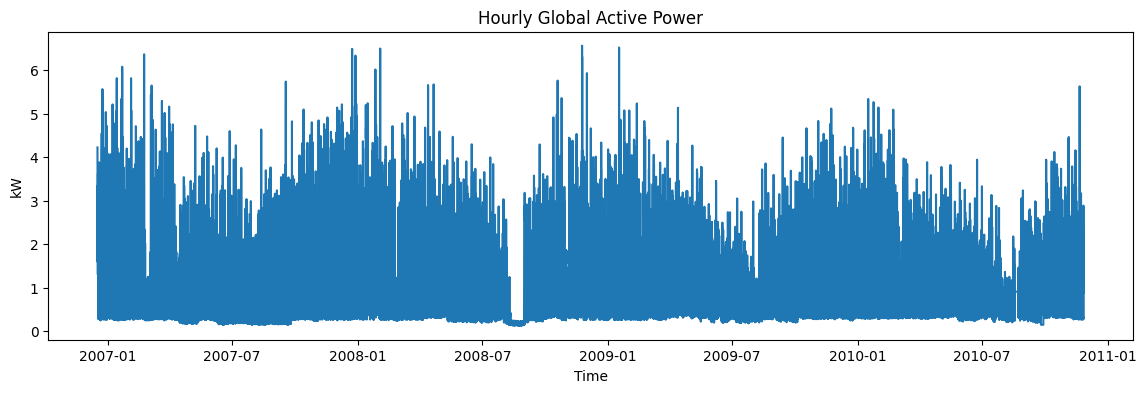

In [31]:
plt.figure(figsize=(14, 4))
plt.plot(power.index, power.values)
plt.title('Hourly Global Active Power')
plt.xlabel('Time')
plt.ylabel('kW')
plt.show()

In [32]:
values = power.values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)
scaled[:10]

array([[0.63681623],
       [0.54504495],
       [0.50900588],
       [0.48854974],
       [0.45559722],
       [0.32255458],
       [0.30103161],
       [0.27320089],
       [0.50110826],
       [0.2273377 ]])

In [33]:
window = 24
X = []
y = []
for i in range(window, len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i])

X = np.array(X)
y = np.array(y)
print(X.shape, y.shape)

(34565, 24, 1) (34565, 1)


In [34]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(len(X_train), len(X_test))

27652 6913


In [35]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

X_train.shape, y_train.shape

(torch.Size([27652, 24, 1]), torch.Size([27652, 1]))

In [36]:
class PowerDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [37]:
train_data = PowerDataset(X_train, y_train)
test_data = PowerDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(len(train_data), len(test_data))

27652 6913


In [38]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, (hidden, cell) = self.lstm(x)
        out = self.fc(hidden[-1])
        return out

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = LSTMModel().to(device)
model

cpu


LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [40]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [41]:
epochs = 15

for epoch in range(epochs):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        pred = model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print('epoch', epoch + 1, '/', epochs, '- loss:', avg_loss)

epoch 1 / 15 - loss: 0.013567754598743095
epoch 2 / 15 - loss: 0.00974687398250019
epoch 3 / 15 - loss: 0.009067916712996832
epoch 4 / 15 - loss: 0.008974890709116917
epoch 5 / 15 - loss: 0.008873451893125375
epoch 6 / 15 - loss: 0.008837015947701268
epoch 7 / 15 - loss: 0.008789317490958865
epoch 8 / 15 - loss: 0.008753248298966582
epoch 9 / 15 - loss: 0.008739523971926498
epoch 10 / 15 - loss: 0.00864757359991448
epoch 11 / 15 - loss: 0.00875614046637511
epoch 12 / 15 - loss: 0.008658346273198586
epoch 13 / 15 - loss: 0.008628260148000876
epoch 14 / 15 - loss: 0.008573681510333322
epoch 15 / 15 - loss: 0.008565017714231828


In [42]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        pred = model(batch_x)
        predictions.extend(pred.cpu().numpy())
        actuals.extend(batch_y.numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

In [43]:
predictions = scaler.inverse_transform(predictions)
actuals = scaler.inverse_transform(actuals)

In [44]:
rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
mae = np.mean(np.abs(predictions - actuals))

print('RMSE:', rmse)
print('MAE:', mae)

RMSE: 0.50118166
MAE: 0.34190556


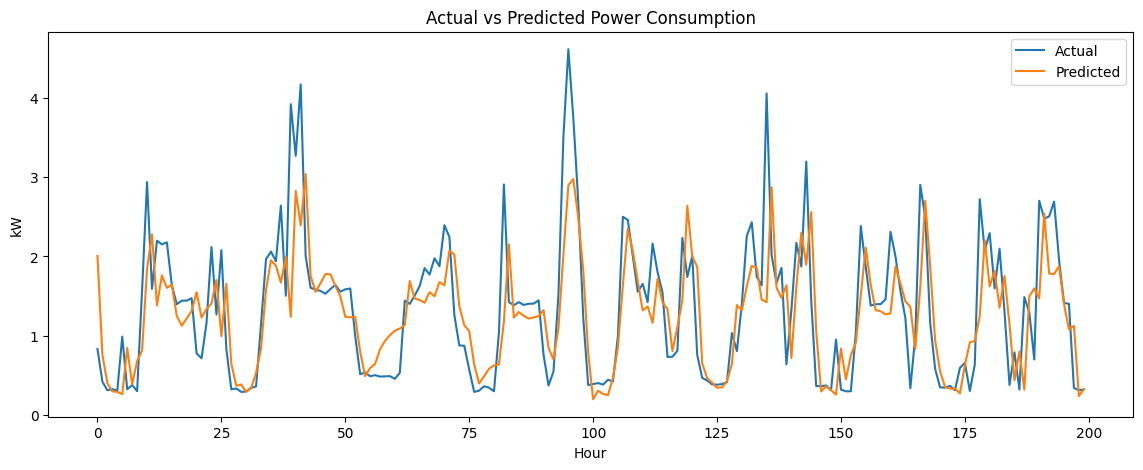

In [45]:
plt.figure(figsize=(14, 5))
plt.plot(actuals[:200], label='Actual')
plt.plot(predictions[:200], label='Predicted')
plt.title('Actual vs Predicted Power Consumption')
plt.xlabel('Hour')
plt.ylabel('kW')
plt.legend()
plt.show()

In [46]:
def predict_next_hour(last_24_hours):
    scaled_input = scaler.transform(np.array(last_24_hours).reshape(-1, 1))
    input_tensor = torch.tensor(scaled_input, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(input_tensor)

    pred_value = scaler.inverse_transform(pred.cpu().numpy())
    return pred_value[0][0]

last_window = power.values[-window:]
result = predict_next_hour(last_window)
print('Predicted next hour power:', result, 'kW')

Predicted next hour power: 0.93191224 kW
